<div class='alert alert-success'>

<h1> Medidas Estatísticas</h1>
<h2 style="font-size: 20px">Análise do conjunto de dados de desmatamento em UCs</h2>

</div>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
arquivo = "tabela_de_desmatamento_ucs_2025.xlsx"

amazonia = pd.read_excel(arquivo,sheet_name="Amazônia",header=1)
amazonia["Bioma"] = "Amazônia"
pantanal = pd.read_excel(arquivo,sheet_name="Pantanal",header=1)
pantanal["Bioma"] = "Pantanal"
mata = pd.read_excel(arquivo,sheet_name="Mata Atlântica",header=1)
mata["Bioma"] = "Mata Atlântica"
pampa = pd.read_excel(arquivo,sheet_name="Pampa",header=1)
pampa["Bioma"] = "Pampa"
cerrado = pd.read_excel(arquivo,sheet_name="Cerrado",header=1)
cerrado["Bioma"] = "Cerrado"
caatinga = pd.read_excel(arquivo,sheet_name="Caatinga",header=1)
caatinga["Bioma"] = "Caatinga"

In [100]:
dfs = [amazonia, pantanal, mata, pampa, cerrado, caatinga]

biomas = ["Amazônia","Pantanal","Mata Atlântica","Pampa","Cerrado","Caatinga"]

for indice,df in enumerate(dfs):
    print(f"=================== {biomas[indice]} ========================")
    df.info()

=================== Amazônia ========================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cnuc                    136 non-null    object 
 1   unidade de conservação  135 non-null    object 
 2   área_ha_uc              135 non-null    float64
 3   Até 2007                135 non-null    float64
 4   2008                    135 non-null    float64
 5   2009                    135 non-null    float64
 6   2010                    135 non-null    float64
 7   2011                    135 non-null    float64
 8   2012                    135 non-null    float64
 9   2013                    135 non-null    float64
 10  2014                    135 non-null    float64
 11  2015                    135 non-null    float64
 12  2016                    135 non-null    float64
 13  2017                    135 non-null    f

<div class='alert alert-success' style='font-size:30px'>

**1. Qual bioma possui a maior área desmatada acumulada?**
</div>

In [101]:
ultimo_total = []

for df in dfs:
    ultimo_total.append(df["TOTAL"].iloc[-1])

print(ultimo_total)

[np.float64(1438278.99), np.float64(7.64), np.float64(394880.87), np.float64(28731.22), np.float64(781758.027), np.float64(947536.334)]


In [102]:
dic_total = {
    "Amazônia": 1438278.99,
    "Pantanal": 7.64,
    "Mata Atlântica": 394880.87,
    "Pampa": 28731.22,
    "Cerrado": 781758.027,
    "Caatinga": 947536.334
}

bioma_total = pd.DataFrame(dic_total.items(), columns=["Bioma", "Total"]).sort_values(by="Total")
bioma_total

,Bioma,Total
1,Pantanal,7.640
3,Pampa,28731.220
2,Mata Atlântica,394880.870
4,Cerrado,781758.027
5,Caatinga,947536.334
0,Amazônia,1438278.990


Text(0, 0.5, '')

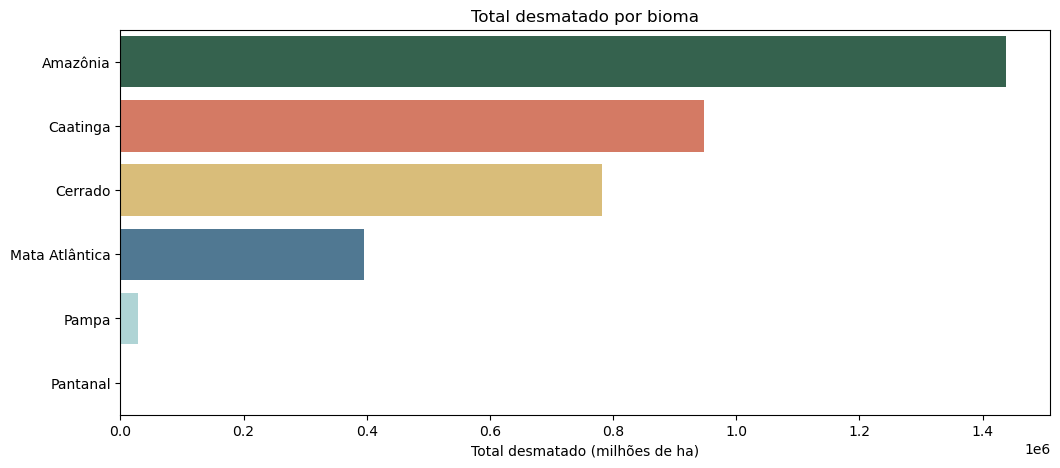

In [103]:
cores = {
    'Amazônia':      '#2d6a4f',
    'Cerrado':       '#e9c46a',
    'Caatinga':      '#e76f51',
    'Mata Atlântica':'#457b9d',
    'Pampa':         '#a8dadc',
    'Pantanal':      '#264653',
}
plt.figure(figsize=(12,5))
sns.barplot(data=bioma_total,y="Bioma",x="Total", hue="Bioma", palette=cores)

plt.gca().invert_yaxis()

plt.title("Total desmatado por bioma")
plt.xlabel("Total desmatado (milhões de ha)")
plt.ylabel("")

<div class="alert alert-info">

**A Amazônia apresentou o maior total acumulado de desmatamento, enquanto o Pantanal apresentou o menor valor. Isso mostra diferenças muito grandes entre os biomas brasileiros.**

</div>

<div class='alert alert-success' style='font-size:30px'>

**2. Quais unidades de conservação possuem os maiores valores de desmatamento?**
</div>

In [104]:
todos_df = pd.concat(dfs,ignore_index=True)
todos_df = todos_df[todos_df['unidade de conservação'].notna()]   
top10 = todos_df.sort_values(by="TOTAL", ascending=False).head(10)
top10 = top10[["unidade de conservação","TOTAL"]].reset_index(drop=True)
top10.columns = ["UCs","TOTAL"]
top10

,UCs,TOTAL
0,APA da Chapada do Araripe,577398.91
1,APA Serra da Ibiapaba,244612.56
2,APA do Planalto Central,236787.84
3,FLONA do Jamanxim,227634.31
4,APA da Bacia do Rio Paraíba do Sul,146252.70
5,APA da Serra da Mantiqueira,145507.91
6,APA do Tapajós,145493.01
7,APA Serra da Ibiapaba,130992.50
8,RESEX Chico Mendes,97410.09
9,REBIO do Gurupi,84632.54


In [105]:
print("\nTOP 10 UCs mais desmatadas:")
print(top10)


TOP 10 UCs mais desmatadas:
                                  UCs      TOTAL
0           APA da Chapada do Araripe  577398.91
1               APA Serra da Ibiapaba  244612.56
2             APA do Planalto Central  236787.84
3                   FLONA do Jamanxim  227634.31
4  APA da Bacia do Rio Paraíba do Sul  146252.70
5         APA da Serra da Mantiqueira  145507.91
6                      APA do Tapajós  145493.01
7               APA Serra da Ibiapaba  130992.50
8                  RESEX Chico Mendes   97410.09
9                     REBIO do Gurupi   84632.54


Text(0.5, 1.0, '10 UCs com maior desmatamento acumulado')

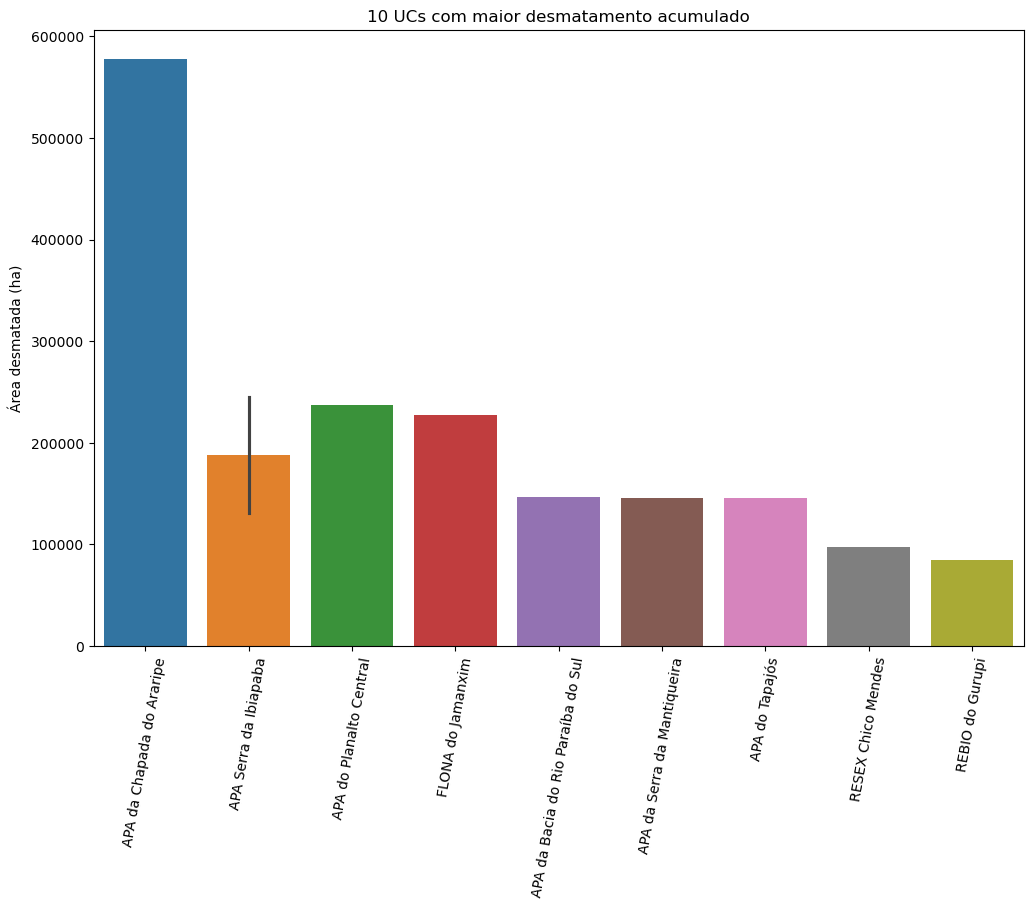

In [106]:
plt.figure(figsize=(12, 8))
sns.barplot(data=top10,x="UCs",y="TOTAL", hue="UCs")

plt.xticks(rotation=80)
plt.xlabel("")
plt.ylabel("Área desmatada (ha)")
plt.title("10 UCs com maior desmatamento acumulado")

<div class="alert alert-info">

**Poucas unidades de conservação concentram os maiores valores acumulados. Isso indica que a pressão ambiental não ocorre de maneira uniforme.**

</div>

<div class='alert alert-success' style='font-size:30px'>

**3. Como o desmatamento evoluiu ao longo dos anos na Amazônia?**
</div>

In [107]:
amazonia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cnuc                    136 non-null    object 
 1   unidade de conservação  135 non-null    object 
 2   área_ha_uc              135 non-null    float64
 3   Até 2007                135 non-null    float64
 4   2008                    135 non-null    float64
 5   2009                    135 non-null    float64
 6   2010                    135 non-null    float64
 7   2011                    135 non-null    float64
 8   2012                    135 non-null    float64
 9   2013                    135 non-null    float64
 10  2014                    135 non-null    float64
 11  2015                    135 non-null    float64
 12  2016                    135 non-null    float64
 13  2017                    135 non-null    float64
 14  2018                    135 non-null    fl

In [108]:
ultimas = amazonia.iloc[-1, 4:21]
ultimas = ultimas.to_dict()
amazonia_anos = pd.DataFrame([ultimas])
amazonia_anos

,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,33965.16,26271.75,17664.8,13699.32,19329.39,20090.96,20280.54,21781.2,21990.09,17306.62,24264.61,44390.23,49842.87,61706.21,51847.23,19449.84,20783


Text(0.5, 1.0, 'Área desmatada da amazônia ao longo dos anos')

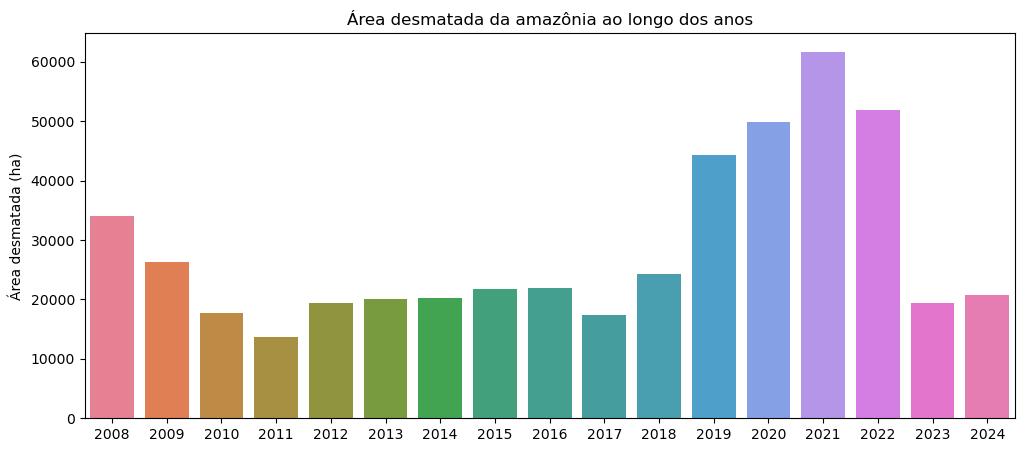

In [109]:
plt.figure(figsize=(12,5))
sns.barplot(data=amazonia_anos)
plt.ylabel("Área desmatada (ha)")
plt.title("Área desmatada da amazônia ao longo dos anos")

<div class="alert alert-info">

**A Amazônia apresentou oscilações importantes ao longo do tempo, com alguns anos registrando crescimento significativo das áreas desmatadas.**

</div>

<div class='alert alert-success' style='font-size:30px'>

**4. Existe desigualdade entre os biomas em relação ao desmatamento? Além disso, o desmatamento está concentrado em áreas específicas?**
</div>

Text(0, 0.5, '')

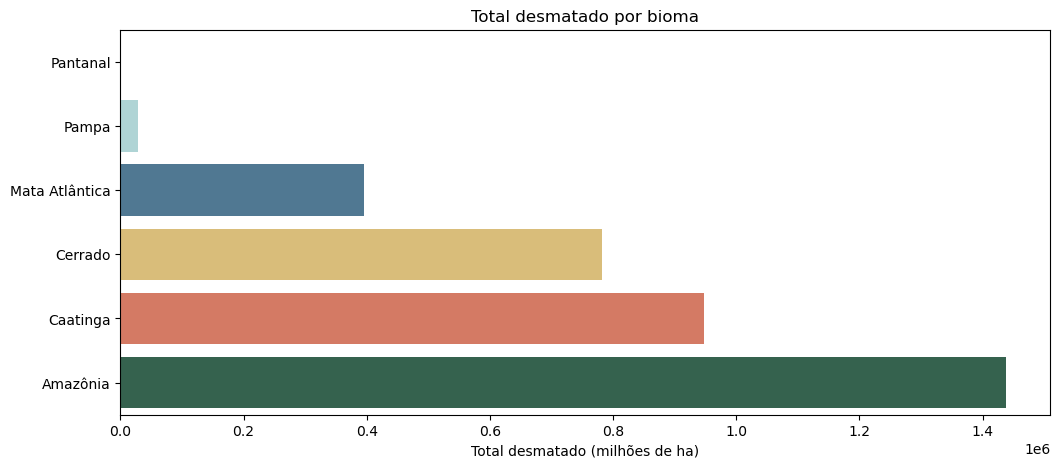

In [110]:
cores = {
    'Amazônia':      '#2d6a4f',
    'Cerrado':       '#e9c46a',
    'Caatinga':      '#e76f51',
    'Mata Atlântica':'#457b9d',
    'Pampa':         '#a8dadc',
    'Pantanal':      '#264653',
}
plt.figure(figsize=(12,5))
sns.barplot(data=bioma_total,y="Bioma",x="Total", hue="Bioma", palette=cores)

plt.title("Total desmatado por bioma")
plt.xlabel("Total desmatado (milhões de ha)")
plt.ylabel("")

<div class="alert alert-info">

**Sim. Alguns biomas apresentam números extremamente altos, enquanto outros mantêm valores relativamente baixos e é possivel notar a concentração em determinadas unidades de conservação, especialmente em áreas extensas.**

</div>

<div class='alert alert-success' style='font-size:30px'>

**5. Quais UCs concentram a maior parte do desmatamento acumulado?**
</div>

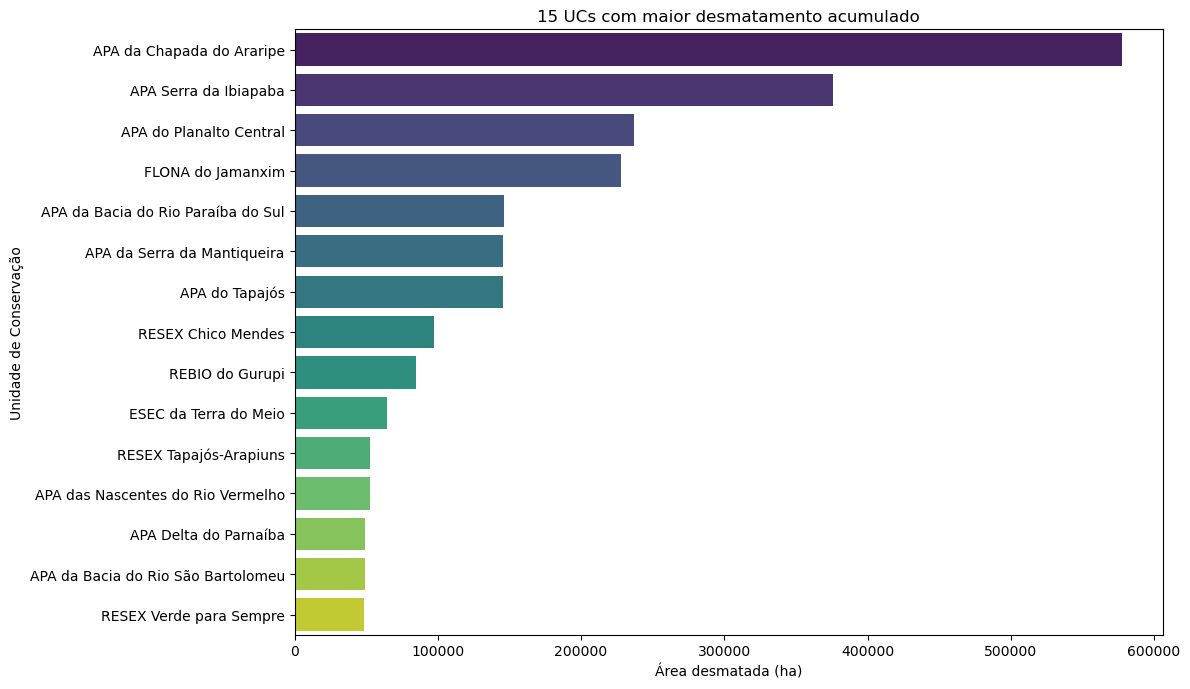

In [111]:
top_ucs = (todos_df.groupby("unidade de conservação")["TOTAL"].sum().sort_values(ascending=False).head(15).reset_index())

plt.figure(figsize=(12,7))

sns.barplot(data=top_ucs,y="unidade de conservação",x="TOTAL",hue="unidade de conservação",palette="viridis")

plt.title("15 UCs com maior desmatamento acumulado")
plt.xlabel("Área desmatada (ha)")
plt.ylabel("Unidade de Conservação")

plt.tight_layout()
plt.show()

<div class="alert alert-info">

**Observa-se que poucas unidades de conservação apresentam valores extremamente elevados de desmatamento quando comparadas. Isso indica concentração da pressão ambiental em áreas específicas.**

</div>

<div class='alert alert-success' style='font-size:30px'>

**6. Qual bioma apresenta maior variação de desmatamento ao longo dos anos?**
</div>

In [113]:
anos = todos_df.iloc[:, 4:21]
anos


,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,119.53,0.00,5.15,0.00,0.00,10.63,0.00,0.00,0.09,0.00,0.00,9.81,23.75,7.68,14.29,0.00,2.0
1,1648.94,1523.54,829.74,1352.57,2238.81,3246.37,2872.94,3437.89,3143.69,3229.61,3895.20,6552.78,6963.76,10646.08,11140.01,4879.10,5587.0
2,0.00,24.53,4.32,16.52,0.00,0.00,0.00,0.00,11.59,26.83,11.19,40.52,0.00,20.45,29.66,1.71,0.0
3,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
4,13.01,25.32,28.75,34.40,222.00,26.89,132.50,89.38,78.45,61.09,55.34,70.91,57.78,119.10,61.31,90.59,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,0.00,NaN,14.70,0.00,NaN,5.94,0.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN
329,0.00,NaN,30.13,0.00,NaN,0.00,0.00,NaN,2.89,0.00,0.00,12.68,0.00,0.00,0.00,0.00,NaN
330,7.68,NaN,17.78,0.00,NaN,19.26,9.08,NaN,3.65,0.00,0.00,6.27,4.79,3.23,0.00,1.45,NaN
331,32.18,NaN,14.57,0.00,NaN,1.31,0.00,NaN,27.94,0.00,0.00,1.53,0.00,0.00,12.59,13.99,NaN


In [ ]:
anos["Bioma"] = todos_df["Bioma"]

soma_anos = anos.groupby("Bioma").sum().T
soma_anos

Bioma,Amazônia,Caatinga,Cerrado,Mata Atlântica,Pampa,Pantanal
2008,33965.16,41031.330,28528.380,9083.67,699.32,0.0
2009,26271.75,0.000,0.000,0.00,0.00,0.0
2010,17664.80,40104.590,23861.530,4963.21,838.76,0.0
2011,13699.32,10672.690,0.000,2162.78,681.07,0.0
2012,19329.39,0.000,17822.510,0.00,0.00,0.0
2013,20090.96,20820.980,20173.910,2576.14,1707.33,0.0
2014,20280.54,10648.800,12706.650,1447.52,331.18,0.0
2015,21781.20,0.000,6326.910,0.00,0.00,0.0
2016,21990.09,13778.980,6066.300,2059.04,575.37,0.0
2017,17306.62,10671.560,3712.070,1185.46,754.17,0.0


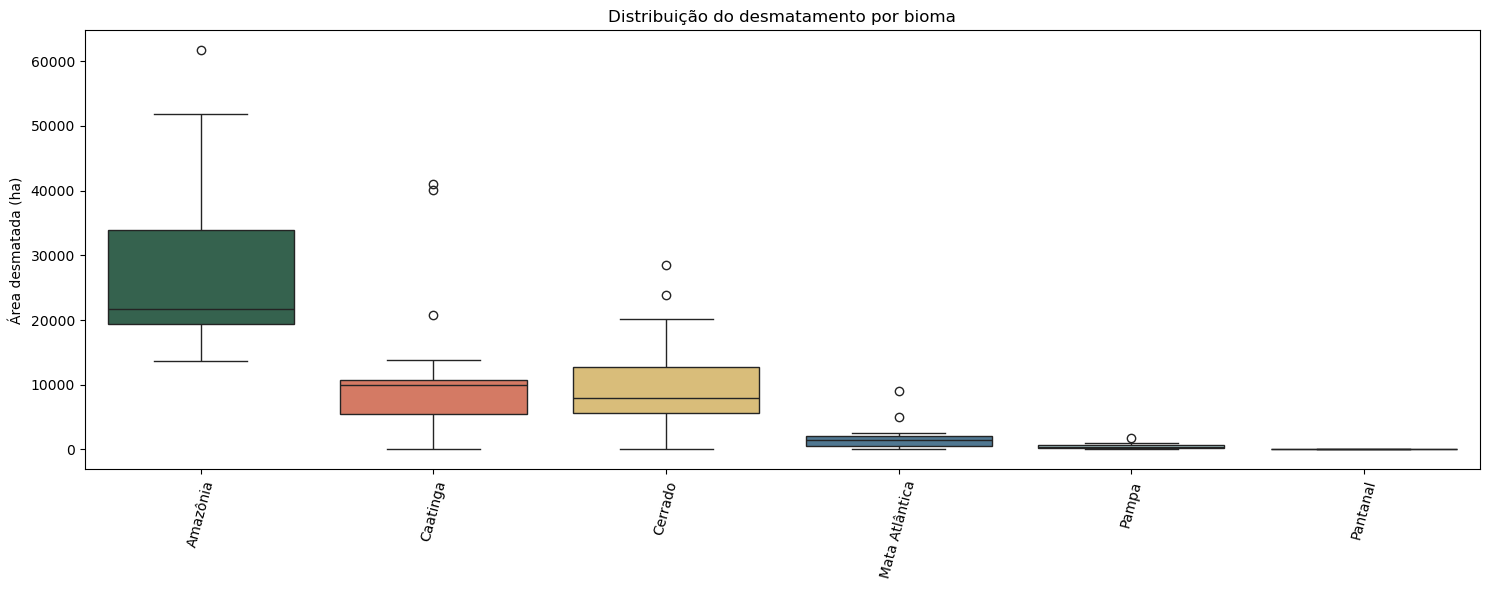

In [122]:
variaveis = ["Amazônia","Caatinga","Cerrado","Mata Atlântica","Pampa","Pantanal"]

plt.figure(figsize=(15,6))

sns.boxplot(data=soma_anos[variaveis],palette=cores)

plt.xticks(rotation=75)

plt.title("Distribuição do desmatamento por bioma")
plt.xlabel("")
plt.ylabel("Área desmatada (ha)")

plt.tight_layout()
plt.show()

<div class="alert alert-info">

**O boxplot mostra diferenças significativas entre os biomas em relação à distribuição do desmatamento ao longo dos anos. A Amazônia e o Cerrado apresentam maior dispersão dos dados, indicando grande variação anual. Já Pantanal e Pampa possuem distribuições mais concentradas, sugerindo maior estabilidade nos valores observados.**

</div>